In [2]:
import cv2

In [3]:
img = cv2.imread("data/OIP-1977465204.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
thresh = cv2.adaptiveThreshold(
    blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV, 11, 2
)

thresh

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(474, 474), dtype=uint8)

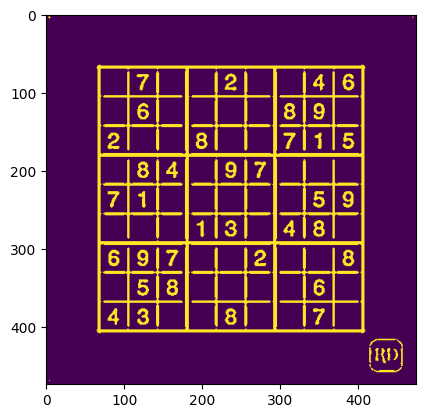

In [4]:
import matplotlib.pyplot as plt

plt.imshow(thresh)

In [5]:
import numpy as np

def reorder(points):
    """
    The function reorder takes four points from a contour of a square)
    and returns them in a consistent order:
      - top-left
      - top-right,
      - bottom-right,
      - bottom-left.
    """
    points = points.reshape((4, 2))
    new_points = np.zeros((4, 2), dtype=np.float32)

    add = points.sum(1)
    new_points[0] = points[np.argmin(add)]  # top-left
    new_points[2] = points[np.argmax(add)]  # bottom-right

    diff = np.diff(points, axis=1)
    new_points[1] = points[np.argmin(diff)]  # top-right
    new_points[3] = points[np.argmax(diff)]  # bottom-left

    return new_points

def extract_grid(img_thresh, side=450):
    """
    This function is responsible for extracting of the
    grid from the image for the easy processing of the
    grid in the EasyOCR(Optical Character Recognition)
    """
    
    # Finding contours for the image
    contours, _ = cv2.findContours(
        img_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    contour = max(contours, key=cv2.contourArea)

    peri = cv2.arcLength(contour, True)  # frame for the sukoku

    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    points = reorder(approx)

    pts1 = np.float32(points)
    pts2 = np.float32([[0, 0], [side, 0], [side, side], [0, side]])

    matrix = cv2.getPerspectiveTransform(pts1, pts2)
    warped = cv2.warpPerspective(img, matrix, (side, side))

    return warped

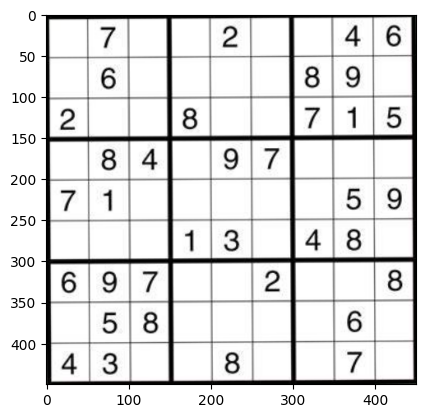

In [6]:
grid = extract_grid(thresh)

plt.imshow(grid)

In [7]:
def read_grid(grid):
    digits = []

    cell_h = grid.shape[0] // 9
    cell_w = grid.shape[1] // 9

    for i in range(9):
        for j in range(9):
            y1, y2 = i * cell_h, (i + 1) * cell_h
            x1, x2 = j * cell_w, (j + 1) * cell_w
            cell = grid[y1:y2, x1:x2]
            digits.append(cell)

    return digits

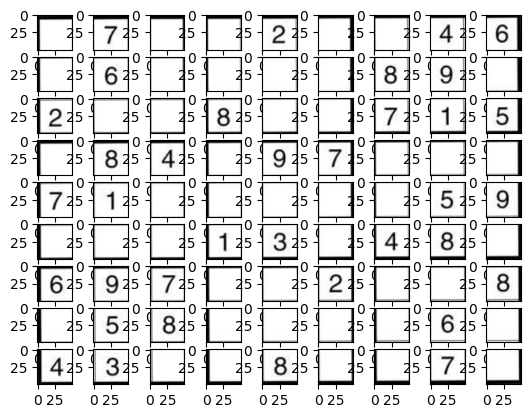

In [8]:
for i, cell in enumerate(read_grid(grid)):
    plt.subplot(9, 9, i+1)
    plt.imshow(cell)

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


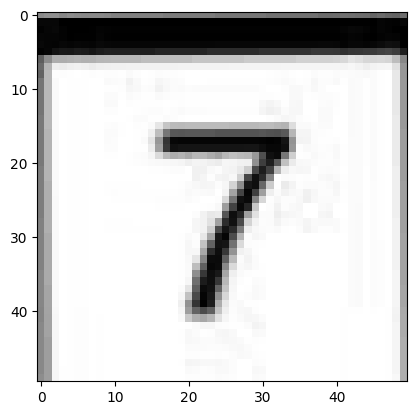

In [9]:
from paddleocr import PaddleOCR

digits = read_grid(grid)

plt.imshow(digits[1])

In [10]:
ocr = PaddleOCR(lang='en')
results = ocr.predict(digits[1])

results

/home/cian/sudoku_solver/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/cian/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/cian/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/cian/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model 

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[138, ..., 138],
           ...,
           [110, ..., 110]],
   
          ...,
   
          [[141, ..., 141],
           ...,
           [174, ..., 174]]], shape=(50, 50, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[138, ..., 138],
           ...,
           [110, ..., 110]],
   
          ...,
   
          [[141, ..., 141],
           ...,
           [174, ..., 174]]], shape=(50, 50, 3), dtype=uint8),
   'output_img': array([[[213, ..., 213],
           ...,
           [241, ..., 241]],
   
          ...,
   
          [[253, ..., 253],
           ...,
           [255, ..., 255]]], shape=(50, 50, 3), dtype=uint8)},
  'dt_polys': [array([[ 8,  5],
          ...,
          [ 8, 48]], shape=(4, 2), dtype=int16)],
  'model_settings': {'use_doc_prep

In [11]:
results[0]["rec_texts"]

['7']

In [12]:
probs = []
for i, im in enumerate(digits):
    res = ocr.predict(im)
    pred = res[0]["rec_texts"]
    probs.append(res[0]["rec_scores"])
    if len(pred) > 0 and pred[0].isdigit():
        print(pred[0], end=" ")
    else:
        print(0, end=" ")
    if (i + 1) % 9 == 0:
        print("")

0 7 0 0 2 0 0 4 9 
0 6 0 0 0 0 8 6 0 
2 0 0 8 0 0 7 1 5 
0 8 4 0 9 7 0 0 0 
7 1 0 0 0 0 0 5 9 
0 0 0 1 3 0 4 8 0 
6 9 7 0 0 2 0 0 8 
0 5 8 0 0 0 0 6 0 
4 3 0 0 8 0 0 7 0 


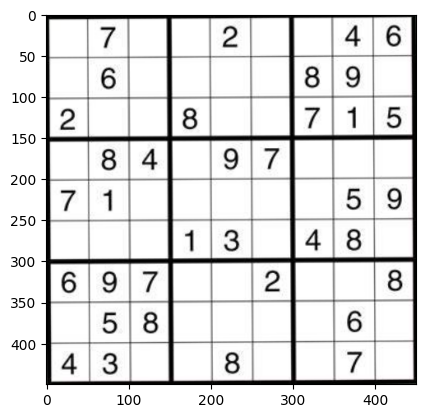

In [13]:
plt.imshow(grid)

In [14]:
probs[8]

[0.9997687935829163]

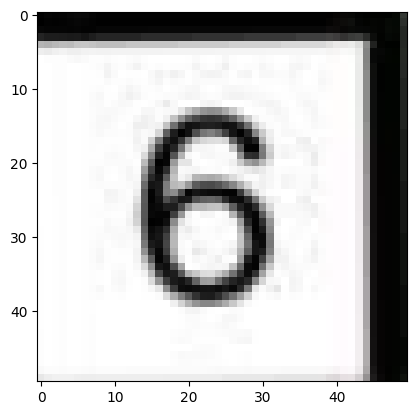

In [15]:
plt.imshow(digits[8])